# Coding Task: Comparing Classifiers – Naive Bayes, K‑NN, Decision Tree, and PLA

**Goal:** Compare four fundamentally different classifiers on synthetic data under various conditions (noise, irrelevant features, small sample size). Understand their inductive biases and performance trade‑offs.

## What You Will Do

1. Generate a **2‑class synthetic dataset** with 2 informative features + optionally irrelevant features.
2. Train and evaluate:
   - **Naive Bayes** (GaussianNB)
   - **K‑Nearest Neighbours** (K=5)
   - **Decision Tree** (max_depth=5)
   - **PLA** (Perceptron from scikit‑learn – sklearn.linear_model.Perceptron)
3. Compare **test accuracy**, **decision boundaries**, and **robustness** under:
   - Clean data (no noise, no irrelevant features)
   - Label noise (flip 10% of training labels)
   - Addition of irrelevant features (3 random Gaussian features)
   - Very small training set (only 20 samples)
4. Answer the questions at the end.

**Deliverable:** Submit this notebook with all cells executed and your answers.

---

In [1]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.naive_bayes import GaussianNB
from sklearn.neighbors import KNeighborsClassifier
from sklearn.tree import DecisionTreeClassifier
from sklearn.linear_model import Perceptron
from sklearn.metrics import accuracy_score
from sklearn.datasets import make_classification

# Set random seed for reproducibility
np.random.seed(42)

def generate_data(n_samples=500, noise_frac=0.0, n_irrelevant=0, flip_y=0.0):
    """
    Generate a binary classification dataset with 2 informative features.
    - noise_frac: not used directly; we use flip_y for label noise.
    - n_irrelevant: number of random Gaussian features to append.
    - flip_y: fraction of labels to flip (label noise).
    """
    X, y = make_classification(n_samples=n_samples, n_features=2, n_redundant=0,
                               n_clusters_per_class=1, n_classes=2,
                               flip_y=flip_y, random_state=42)
    # Add irrelevant features if requested
    if n_irrelevant > 0:
        X_irr = np.random.randn(n_samples, n_irrelevant)
        X = np.hstack([X, X_irr])
    return X, y

# Generate clean dataset (no noise, no irrelevant features)
X_clean, y_clean = generate_data(n_samples=500, flip_y=0.0, n_irrelevant=0)

# Split into train (70%) and test (30%)
X_train, X_test, y_train, y_test = train_test_split(X_clean, y_clean, test_size=0.3, random_state=42)

print(f"Training samples: {X_train.shape[0]}, Test samples: {X_test.shape[0]}")
print(f"Features: {X_train.shape[1]}")

Training samples: 350, Test samples: 150
Features: 2


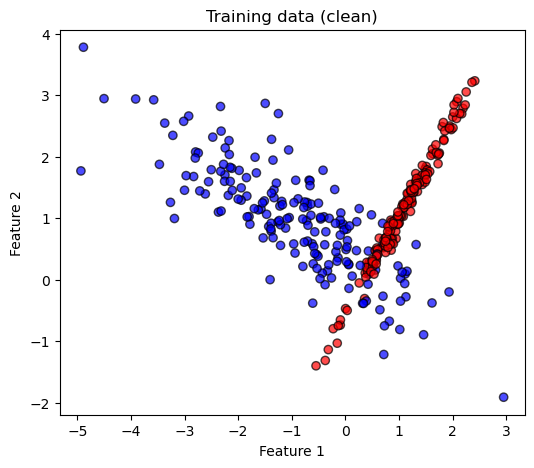

In [3]:
plt.figure(figsize=(6,5))
plt.scatter(X_train[:,0], X_train[:,1], c=y_train, cmap='bwr', edgecolors='k', alpha=0.7)
plt.xlabel('Feature 1')
plt.ylabel('Feature 2')
plt.title('Training data (clean)')
plt.show()

In [ ]:
def train_and_evaluate(clf, X_train, y_train, X_test, y_test):
    """Train a classifier and return train and test accuracy."""
    clf.fit(X_train, y_train)
    train_acc = accuracy_score(y_train, clf.predict(X_train))
    test_acc = accuracy_score(y_test, clf.predict(X_test))
    return train_acc, test_acc

# TODO: Create instances of the four classifiers
# nb = GaussianNB()
# knn = KNeighborsClassifier(n_neighbors=5)
# dt = DecisionTreeClassifier(max_depth=5, random_state=42)
# pla = Perceptron(max_iter=1000, random_state=42)

classifiers = [nb, knn, dt, pla]
names = ['Naive Bayes', 'KNN (K=5)', 'Decision Tree (depth=5)', 'PLA (Perceptron)']

print("Clean dataset (no noise, no irrelevant features):")
print(f"{'Classifier':<20} {'Train acc':<12} {'Test acc':<12}")
for name, clf in zip(names, classifiers):
    tr, te = train_and_evaluate(clf, X_train, y_train, X_test, y_test)
    print(f"{name:<20} {tr:<12.4f} {te:<12.4f}")

In [ ]:
def plot_decision_boundary(clf, X, y, title):
    """Plot decision boundary for 2D data (first two features)."""
    x_min, x_max = X[:,0].min() - 0.5, X[:,0].max() + 0.5
    y_min, y_max = X[:,1].min() - 0.5, X[:,1].max() + 0.5
    xx, yy = np.meshgrid(np.linspace(x_min, x_max, 200),
                         np.linspace(y_min, y_max, 200))
    # Use only first two features for prediction
    Z = clf.predict(np.c_[xx.ravel(), yy.ravel()])
    Z = Z.reshape(xx.shape)
    plt.contourf(xx, yy, Z, alpha=0.3, cmap='bwr')
    plt.scatter(X[:,0], X[:,1], c=y, cmap='bwr', edgecolors='k')
    plt.xlabel('Feature 1')
    plt.ylabel('Feature 2')
    plt.title(title)
    plt.show()

In [ ]:
# TODO: Train each classifier again (or reuse) and call plot_decision_boundary
# Use X_train[:,:2] because we only want first 2 features for 2D plot

In [ ]:
# Generate dataset with 10% label noise
X_noisy, y_noisy = generate_data(n_samples=500, flip_y=0.1, n_irrelevant=0)
X_train_n, X_test_n, y_train_n, y_test_n = train_test_split(X_noisy, y_noisy, test_size=0.3, random_state=42)

print("Dataset with 10% label noise:")
print(f"{'Classifier':<20} {'Train acc':<12} {'Test acc':<12}")
for name, clf in zip(names, classifiers):
    # TODO: reinitialize classifiers (or copy) to avoid using previously fitted ones
    # Hint: create new instances inside the loop
    pass

In [ ]:
# Generate dataset with 3 irrelevant features (total 5 features)
X_irr, y_irr = generate_data(n_samples=500, flip_y=0.0, n_irrelevant=3)
X_train_i, X_test_i, y_train_i, y_test_i = train_test_split(X_irr, y_irr, test_size=0.3, random_state=42)

print("Dataset with 3 irrelevant features (total 5 features):")
# TODO: evaluate classifiers again (use only first 2 features for decision boundary but all features for training)
# For decision boundary plot, still use first two features

In [ ]:
X_small, y_small = generate_data(n_samples=200, flip_y=0.0, n_irrelevant=0)
X_train_s, X_test_s, y_train_s, y_test_s = train_test_split(X_small, y_small, test_size=0.3, random_state=42)
X_train_s = X_train_s[:20]   # force only 20 training samples
y_train_s = y_train_s[:20]

print("Very small training set (20 samples):")
# TODO: evaluate classifiers

## Questions to Answer

Write your answers below (double‑click to edit this cell).

1. **On clean data, which classifier gave the highest test accuracy? Which gave the lowest? What does this tell you about the data separability?**

2. **After adding 10% label noise, which classifier’s performance degraded the most? Which was most robust? Why?**

3. **When 3 irrelevant features were added, how did the performance of each classifier change? Which model was most affected? Why?**

4. **With only 20 training samples, which classifier performed best? Which performed worst? Explain in terms of bias‑variance.**

5. **Look at the decision boundaries for clean data. Which classifier produced a linear boundary? Which produced a non‑linear, step‑wise boundary? Which produced a smooth curved boundary?**

6. **If you had to deploy a model in a medical diagnosis system where interpretability is critical, which model would you choose? Why?**